In [1]:
!pip install pennylane
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.1 MB/s eta 0:00:00


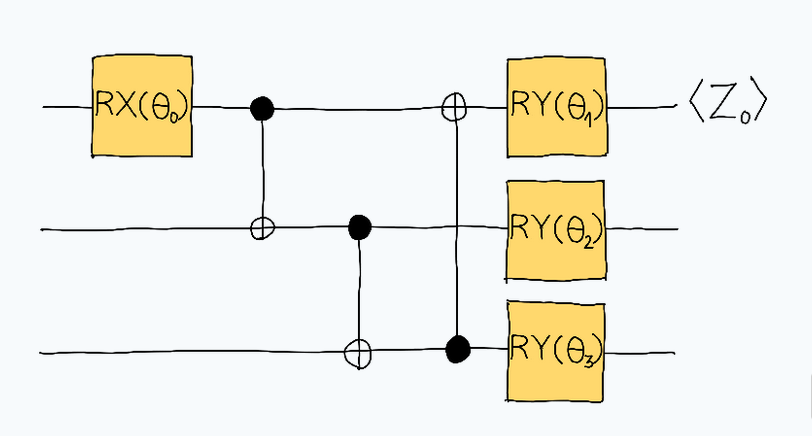

In [2]:
dev = qml.device("default.qubit", wires = 3)

@qml.qnode(dev)
def circuit_as_function(params):
    """
    Implements the circuit shown in the codercise statement.
    Args:
    - params (np.ndarray): [theta_0, theta_1, theta_2, theta_3]
    Returns:
    - (np.tensor): <Z0>
    """

    qml.RX(params[0], wires=0)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,0])
    qml.RY(params[1], wires=0)
    qml.RY(params[2], wires=1)
    qml.RY(params[3], wires=2)

    return qml.expval(qml.PauliZ(0))

angles = np.linspace(0, 4 * np.pi, 200)
output_values = np.array([circuit_as_function([0.5, t, 0.5, 0.5]) for t in angles])

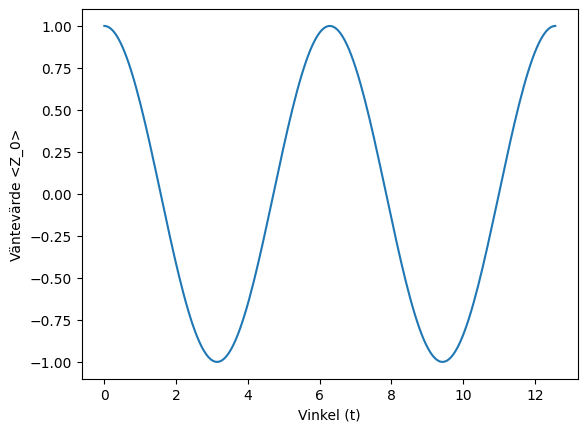

In [3]:
plt.plot(angles, output_values)
plt.xlabel("Vinkel (t)")
plt.ylabel("Väntevärde <Z_0>")
plt.show()

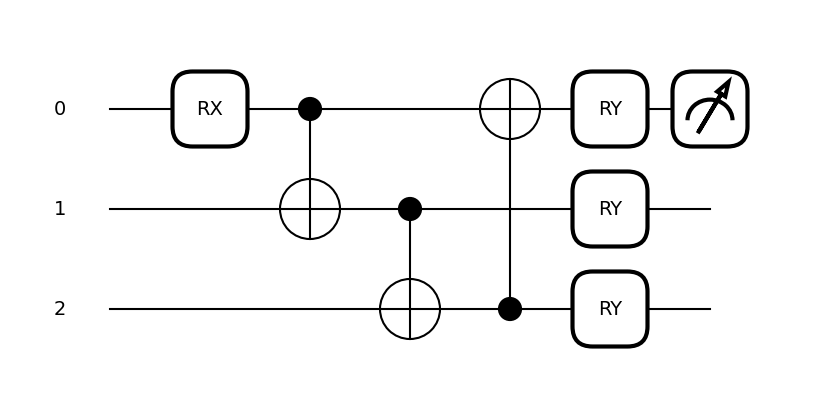

In [4]:
qml.draw_mpl(circuit_as_function)([0.5, 1.0, 0.5, 0.5])
plt.show()